# Game Theory on Complex Networks
Playground to figure out network generation, update rules and simulations.

In [1]:
import networkx as nx 
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm.auto import tqdm 
import time
import os
import h5py
from numba import njit
from joblib import Parallel, delayed


np.random.seed(13)

### 1. Network Generation
Let's try to implement the network generation as described by [Gómez-Gardeñes et al., 2006](http://dx.doi.org/10.1103/PhysRevE.73.056124)

In [2]:
def generate_mixed_network(N:int=1000, alpha:float=0.0, m:int=4, m0_frac:float=0.1) -> nx.Graph:
    """Generates network according to mixed model by Gómez-Gardeñes and Moreno (2006),
    which interpolates between ER and BA model through the heterogeneity parameter alpha.

    Args:
        N (int, optional): Number of nodes. Defaults to 1000.
        alpha (float, optional): Heterogeneity parameter, can have values from 0 (BA-graph) 
            to 1 (ER-graph). Defaults to 0.0.
        m (int, optional): Number of edges added at each growth step. Defaults to 6.
        m0_frac (float, optional): Fraction of total nodes to form the initial fully connected
            graph before the growing process. Defaults to 0.1.

    Returns:
        nx.Graph: Output networkx graph.
    """
    m0 = int(N*m0_frac)
    G = nx.complete_graph(m0)  # initialise fully connected network with m0 nodes
    U_idx = np.arange(m0, N) # indices of N-m0 initially unconnected nodes
    G.add_nodes_from(U_idx)  # add the N-m0 unconnected nodes

    E = G.number_of_edges() # keeping track manually instead of extracting from graph in loop
    degree = np.zeros(N, dtype=int) # keeping track of degrees in a numpy array instead
    degree[:m0] = m0-1  # degree of the m0 nodes in the initial complete graph

    node_indices = np.arange(N) # used for masking later

    # we'll have to go through all N-m0 unconnected nodes, each selected randomly
    # let's do this by shuffeling the index list and go through the nodes in the
    # obtained random order
    np.random.shuffle(U_idx)

    for idx in U_idx:
        # create m links:
        for _ in range(m):
            # TODO: catch cases with no initial edges etc!
            # (re)compute node probs:
            mask = node_indices != idx # mask to get all nodes except current one
            # with probability alpha select a uniformly random one of all nods
            # with probability 1-alpha select node via preferential attachment
            probs = (1.0-alpha)*degree[mask]/(2*E - degree[idx]) +  alpha*1/(N-1)
            node = np.random.choice(node_indices[mask], p=probs)
            G.add_edge(idx, node) # add edge to graph

            degree[idx] += 1 # update degrees
            degree[node] += 1
            E += 1  # increment total number of edges

    return G

50
161


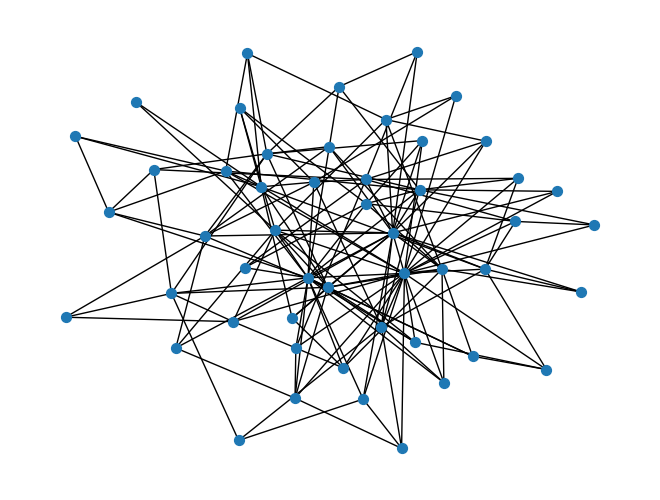

In [3]:
G = generate_mixed_network(N=50)
print(G.number_of_nodes())
print(G.number_of_edges())
nx.draw(G, node_size=50)

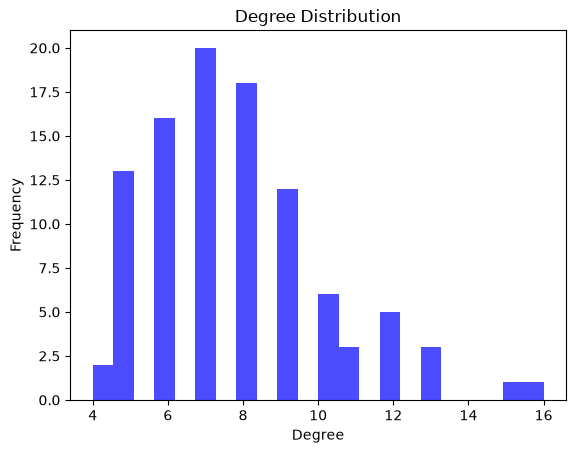

In [4]:
# plot degree distribution - ER case
G = generate_mixed_network(N=100, alpha=1.0)
degree_sequence = sorted([d for n, d in G.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

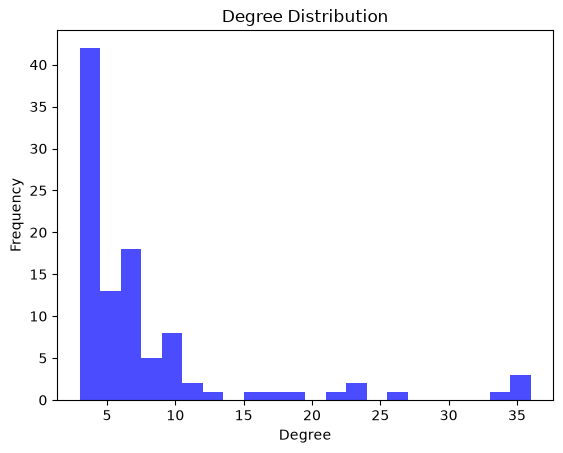

In [5]:
# plot degree distribution - SF case
G = generate_mixed_network(N=100, alpha=0.0)
degree_sequence = sorted([d for n, d in G.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

### Running the Ultimatum game

Defining the update rules:

In [6]:
@njit(cache=True)
def MOR_update(node, nb_row_ptr, nb_col_indices, payoffs, strategies, update_rules):
    start, end = nb_row_ptr[node], nb_row_ptr[node+1] # marking the index range with node's neighbors
    neighbors = nb_col_indices[start:end] # get the neighbors
    n_neighbors = neighbors.shape[0]      

    # aggregate total payoff 
    total = payoffs[node] # need to include the node itself
    for i in range(n_neighbors):
        total += payoffs[neighbors[i]]
    
    if total <= 0: # so if no payoff has been obtained at all
        # make uniformly random choice between all neighbors
        idx = np.random.randint(0, n_neighbors+1)
        if idx == n_neighbors:
            nb_chosen = node
        else:
            nb_chosen = neighbors[idx]
    else:
        # choose neighbor with probability proportional to payoff
        # instead of the weighted np.random.choice, let's do this the old fashioned way
        # via inverse cdf sampling
        r = np.random.random() * total  # generate uniform random var
        cumsum = payoffs[node]
        if r < cumsum: # first check for the node itself
            nb_chosen = node
        else:
            # as a fallback if we somehow get r so close to 1 that for some ungodly reason
            # the r < cumsum doesn't trigger in the last loop
            nb_chosen = neighbors[-1] 
            for i in range(n_neighbors):
                cumsum += payoffs[neighbors[i]]
                if r < cumsum: # we chose our node
                    nb_chosen = neighbors[i]
                    break
    # return strategy and update rule of chosen neighbor (or self)
    return strategies[nb_chosen], update_rules[nb_chosen]

@njit(cache=True)
def REP_update(node, nb_row_ptr, nb_col_indices, payoffs, strategies, update_rules, degrees):
    # corresponds to the "natural selection" rule
    start, end = nb_row_ptr[node], nb_row_ptr[node+1] # marking the index range with node's neighbors
    neighbors = nb_col_indices[start:end] # get the neighbors
    n_neighbors = neighbors.shape[0]      

    # choose random neighbor nb
    idx = np.random.randint(0, n_neighbors)
    nb = neighbors[idx]

    # compute replication probability from payoff difference
    prob = max(0.0, (payoffs[nb] - payoffs[node])/(2*max(degrees[node], degrees[nb])))

    if np.random.random() < prob: # copy nb
        return strategies[nb], update_rules[nb]
    else: # keep current strategy/update rule
        return strategies[node], update_rules[node]
    
    # NOTE TO SELF: KEEP IN MIND THAT UPDATES NEED TO HAPPEN SIMULATANEOUSLY! DO NOT OVERWRITE
    # ANY OF THE STRATEGIES/UPDATE RULES UNTIL ALL NODES HAVE BEEN EVALUTATED!!!
    # BUILD A DICT OF THE NEW THINGS FIRST AND THEN ASSIGN THE NEW ATTRIBUTES
    # determine whether or not to copy neighbor strategy & update rule

@njit(cache=True)
def UI_update(node, nb_row_ptr, nb_col_indices, payoffs, strategies, update_rules):
    # get neighbor with highest payoff and copy if better
    start, end = nb_row_ptr[node], nb_row_ptr[node+1] # marking the index range with node's neighbors
    neighbors = nb_col_indices[start:end] # get the neighbors
    n_neighbors = neighbors.shape[0]  

    best_nb = node
    best_payoff = payoffs[node]
    for i in range(n_neighbors):
        nb = neighbors[i]
        if payoffs[nb] > best_payoff:
            best_payoff = payoffs[nb]
            best_nb = nb

    return strategies[best_nb], update_rules[best_nb]

# dict of update rules pointing to the implemented update functions
UPDATE_RULES_DICT = {
    "MOR": MOR_update,
    "REP": REP_update,
    "UI": UI_update
}

# actually, let's try to use integer codes for the different update rules
# to avoid any pains with strings
RULE_TO_INT = {"MOR": 0, "REP": 1, "UI": 2}
INT_TO_RULE = {v: k for k, v in RULE_TO_INT.items()}

Initialise UG and perform a single round:

In [7]:
def init_UG(G: nx.graph, update_rules, update_ratios, mode:str="fair"):
    # initialise the ultimatum game by assigning initial strategies, update rules
    # and payoffs for each of the nodes in the graph
    N = G.number_of_nodes()  # number of nodes

    # generate strategies
    if mode == "fair":  # p = q
        p_vals = np.random.uniform(size=(N, 1)) 
        strategies = np.column_stack([p_vals, p_vals])
    elif mode == "pragmatic":  # p = 1-q 
        p_vals = np.random.uniform(size=(N, 1))
        strategies = np.column_stack([p_vals, 1-p_vals])
    elif mode == "independent":  # p, q independent
        strategies = np.random.uniform(size=(N, 2))
    else: # invalide mode
        raise ValueError(f"Invalid mode argument. Mode must be 'fair', 'pragmatic', or 'independent'. Given mode: {mode}.")
    # make dictionary with node indices to assign it as node attribute

    # generate update rules
    # we want to randomly assign them to nodes, with the proportions specified by update_ratios
    # or at least as closely as we can
    update_ratios = np.array(update_ratios, dtype=float)
    update_ratios /= sum(update_ratios) # ensure they're normalized
    update_counts_raw = N*update_ratios # figure out the corresponding counts
    update_counts = np.floor(update_counts_raw).astype(int) # round down to integers 
    remaining_slots = N - update_counts.sum() # check how many (if any) slots are missing through the rounding
    if remaining_slots > 0: # increase counts of those with the biggest difference if necessary
        update_counts[np.argsort(update_counts_raw-update_counts)[:N - update_counts.sum()]] += 1
    update_keys = np.repeat(update_rules, update_counts) # generate array of update rules
    np.random.shuffle(update_keys) # shuffle for random assignment

    # return initial strategies, update rules, payoff
    return np.zeros(N, dtype=float), strategies, update_keys

@njit(cache=True)
def run_UG_step(src, trg, nb_row_ptr, nb_col_indices, degrees, strategies_curr, updates_curr):
    # Perform one simulation step, consisting of accumulating payoff and updating strategies/rules.
    # Each node "plays" each neighbor by comparing the respective offers p and thresholds q and 
    # adding the obtained payoff from each game. Then, according to each node's update rule, the 
    # payoffs are compared and strategies/update rules are updated
    N = len(degrees)
    # initialise payoffs to 0.0
    payoffs = np.zeros(N, dtype=float)

    # --------- Payoff resolution ------------
    # Note: right now we do not make use of knowing the player strategy (fair/pragmatic) to compute the
    # payoffs, for the sake of simplicity. Might be something to add later. 
    # go through all edges and resolve the pairwise interactions 
    # p = strategies_curr[:, 0]
    # q = strategies_curr[:, 1]
    # offer_accepted_r1 = p[src] >= q[trg] # round 1
    # offer_accepted_r2 = p[trg] >= q[src] # round 2 (switched roles)

    # accumulate the payoff 
    # round 1: src is proposer, trg is responder
    # np.add.at(payoffs, src[offer_accepted_r1], 1-p[src[offer_accepted_r1]]) # proposer payoff
    # np.add.at(payoffs, trg[offer_accepted_r1], p[src[offer_accepted_r1]]) # responder payoff
    # # round 2: trg is proposer, src is responder (roles switched)
    # np.add.at(payoffs, trg[offer_accepted_r2], 1-p[trg[offer_accepted_r2]]) # proposer payoff
    # np.add.at(payoffs, src[offer_accepted_r2], p[trg[offer_accepted_r2]]) # responder payoff
    # ... god I hope I have this the right way around
    
    for e in range(src.shape[0]): # iterate over edges
        i = src[e]
        j = trg[e]
        # get offer p/threshold q for nodes i, j
        p_i, q_i = strategies_curr[i]
        p_j, q_j = strategies_curr[j]
        # compute & update payoffs
        if p_i >= q_j:  # i proposes, j responds
            payoffs[i] += 1-p_i
            payoffs[j] += p_i
        if p_j >= q_i:  # j proposes, i responds
            payoffs[i] += p_j
            payoffs[j] += 1-p_j

    # --------- Update strategies & rules ---------
    # get lists with new strategies/update rules for each node
    strategies_new = np.empty_like(strategies_curr)
    update_rules_new = np.empty_like(updates_curr)

    for i in range(N):
        update = updates_curr[i]
        if update == 0: # MOR
            strategy_new, update_rule_new = MOR_update(i, nb_row_ptr, nb_col_indices, payoffs, strategies_curr, updates_curr)
        elif update == 1: # REP
            strategy_new, update_rule_new = REP_update(i, nb_row_ptr, nb_col_indices, payoffs, strategies_curr, updates_curr, degrees)
        elif update == 2: # UI
            strategy_new, update_rule_new = UI_update(i, nb_row_ptr, nb_col_indices, payoffs, strategies_curr, updates_curr)

        strategies_new[i] = strategy_new
        update_rules_new[i] = update_rule_new

    return payoffs, strategies_new, update_rules_new

In [8]:
G = generate_mixed_network(N=10, m0_frac=0.2)
payoffs, strategies, updates = init_UG(G, update_rules=["REP"], update_ratios=[1])
for i in range(len(payoffs)):
    print(strategies[i])
    print(updates[i])
    print(payoffs[i])

[0.95916499 0.95916499]
REP
0.0
[0.47112756 0.47112756]
REP
0.0
[0.24914282 0.24914282]
REP
0.0
[0.96519166 0.96519166]
REP
0.0
[0.765947 0.765947]
REP
0.0
[0.40195379 0.40195379]
REP
0.0
[0.51490641 0.51490641]
REP
0.0
[0.79291087 0.79291087]
REP
0.0
[0.98392831 0.98392831]
REP
0.0
[0.71491693 0.71491693]
REP
0.0


In [9]:
edge_arr = np.array(G.edges())
src, trg = edge_arr[:, 0], edge_arr[:, 1]
neighbor_matr = nx.to_scipy_sparse_array(G, format='csr')
row_ptr = neighbor_matr.indptr
col_indices = neighbor_matr.indices
degrees = np.diff(row_ptr)
updates = np.array([RULE_TO_INT[u] for u in updates], dtype=int) # use integers instead

payoffs, strategies, updates = run_UG_step(src, trg, row_ptr, col_indices, degrees, strategies, updates)

for i in range(len(payoffs)):
    print(strategies[i])
    print(updates[i])
    print(payoffs[i])

[0.95916499 0.95916499]
1
2.2349650422072562
[0.47112756 0.47112756]
1
2.7688908354227264
[0.24914282 0.24914282]
1
4.324002435637766
[0.51490641 0.51490641]
1
1.1231616561721127
[0.765947 0.765947]
1
2.2201818670266205
[0.40195379 0.40195379]
1
3.334050374892781
[0.51490641 0.51490641]
1
2.4094502448328248
[0.79291087 0.79291087]
1
2.752713173649369
[0.96519166 0.96519166]
1
0.06428677806233152
[0.71491693 0.71491693]
1
3.768297592096212


### Running the full UG simulation

In [10]:
def run_UG_simulation(file,
                      N=1000,
                      alpha=0.0,
                      m=4,
                      m0_frac=0.1,
                      num_rounds=1000, 
                      update_rules=list(UPDATE_RULES_DICT.keys()), 
                      update_ratios=[1]*len(UPDATE_RULES_DICT.keys()),
                      mode="independent",
                      snapshot_frequency=100,
                      rep_id=0, 
                      ):

    # start timer
    t0 = time.perf_counter()
    # initialize graph
    G = generate_mixed_network(N=N, alpha=alpha, m=m, m0_frac=m0_frac)
    # initialize UG    
    payoffs, strategies, updates = init_UG(G, update_rules, update_ratios, mode=mode)  
    updates = np.array([RULE_TO_INT[u] for u in updates], dtype=int) # use integers instead
    # TODO: INITIALISE UPDATES AS INTEGERS INSTEAD OF STRINGS to avoid the conversion later
    N = G.number_of_nodes()
    # extract graph structure that can be reused
    edge_arr = np.array(G.edges())
    src, trg = edge_arr[:, 0], edge_arr[:, 1]
    neighbor_matr = nx.to_scipy_sparse_array(G, format='csr', nodelist=range(N))
    row_ptr = neighbor_matr.indptr
    col_indices = neighbor_matr.indices
    degrees = np.diff(row_ptr)

    num_rounds_saved = num_rounds // snapshot_frequency
    # initialise result arrays
    res_steps = np.empty(num_rounds_saved, dtype=np.int64)
    res_payoffs = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_p = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_q = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_updates = np.empty((num_rounds_saved, N), dtype=np.uint8)

    # loop over UG rounds
    for round in range(num_rounds):
        # run UG
        payoffs, strategies, updates = run_UG_step(src, trg, row_ptr, col_indices, degrees, strategies, updates)

        # extract result data every couple of rounds to see evolution
        if round%snapshot_frequency == 0:
                round_idx = round//snapshot_frequency
                res_steps[round_idx] = round_idx
                res_payoffs[round_idx, :] = payoffs
                res_p[round_idx, :] = strategies[:, 0]
                res_q[round_idx, :] = strategies[:, 1]
                res_updates[round_idx, :] = updates

    # tracking the runtime
    t1 = time.perf_counter() - t0
    # write results to file
    grp = file.create_group(f"rep_{rep_id}")
    grp.create_dataset("steps", data=res_steps)
    grp.create_dataset("payoffs", data=res_payoffs)
    grp.create_dataset("p", data=res_p)
    grp.create_dataset("q", data=res_q)
    grp.create_dataset("updates", data=res_updates)

    grp.attrs["rep_id"] = rep_id
    grp.attrs["runtime_s"] = t1

    return 0

In [11]:
def run_UG_simulation_old(
                      N=1000,
                      alpha=0.0,
                      m=4,
                      m0_frac=0.1,
                      num_rounds=1000, 
                      update_rules=list(UPDATE_RULES_DICT.keys()), 
                      update_ratios=[1]*len(UPDATE_RULES_DICT.keys()),
                      mode="independent",
                      snapshot_frequency=100,
                      rep_id=0, 
                      ):

    # start timer
    t0 = time.perf_counter()
    # initialize graph
    G = generate_mixed_network(N=N, alpha=alpha, m=m, m0_frac=m0_frac)
    # initialize UG    
    payoffs, strategies, updates = init_UG(G, update_rules, update_ratios, mode=mode)  
    updates = np.array([RULE_TO_INT[u] for u in updates], dtype=int) # use integers instead
    # TODO: INITIALISE UPDATES AS INTEGERS INSTEAD OF STRINGS to avoid the conversion later
    N = G.number_of_nodes()
    # extract graph structure that can be reused
    edge_arr = np.array(G.edges())
    src, trg = edge_arr[:, 0], edge_arr[:, 1]
    neighbor_matr = nx.to_scipy_sparse_array(G, format='csr', nodelist=range(N))
    row_ptr = neighbor_matr.indptr
    col_indices = neighbor_matr.indices
    degrees = np.diff(row_ptr)

    num_rounds_saved = num_rounds // snapshot_frequency
    # initialise result arrays
    res_steps = np.empty(num_rounds_saved, dtype=np.int64)
    res_payoffs = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_p = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_q = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_updates = np.empty((num_rounds_saved, N), dtype=np.uint8)

    # loop over UG rounds
    for round in range(num_rounds):
        # run UG
        payoffs, strategies, updates = run_UG_step(src, trg, row_ptr, col_indices, degrees, strategies, updates)

        # extract result data every couple of rounds to see evolution
        if round%snapshot_frequency == 0:
                round_idx = round//snapshot_frequency
                res_steps[round_idx] = round_idx
                res_payoffs[round_idx, :] = payoffs
                res_p[round_idx, :] = strategies[:, 0]
                res_q[round_idx, :] = strategies[:, 1]
                res_updates[round_idx, :] = updates

    # tracking the runtime
    t1 = time.perf_counter() - t0
    
    return [res_steps, res_payoffs, res_p, res_q, res_updates, t1]

In [12]:
results = run_UG_simulation_old(update_rules=["REP"], update_ratios=[1], num_rounds=2000, snapshot_frequency=1, mode="fair")
# takes ~ 1.5h rn, 3.58 rounds/s with 5k nodes, MOR vs REP 1:1

Plot preliminary results:

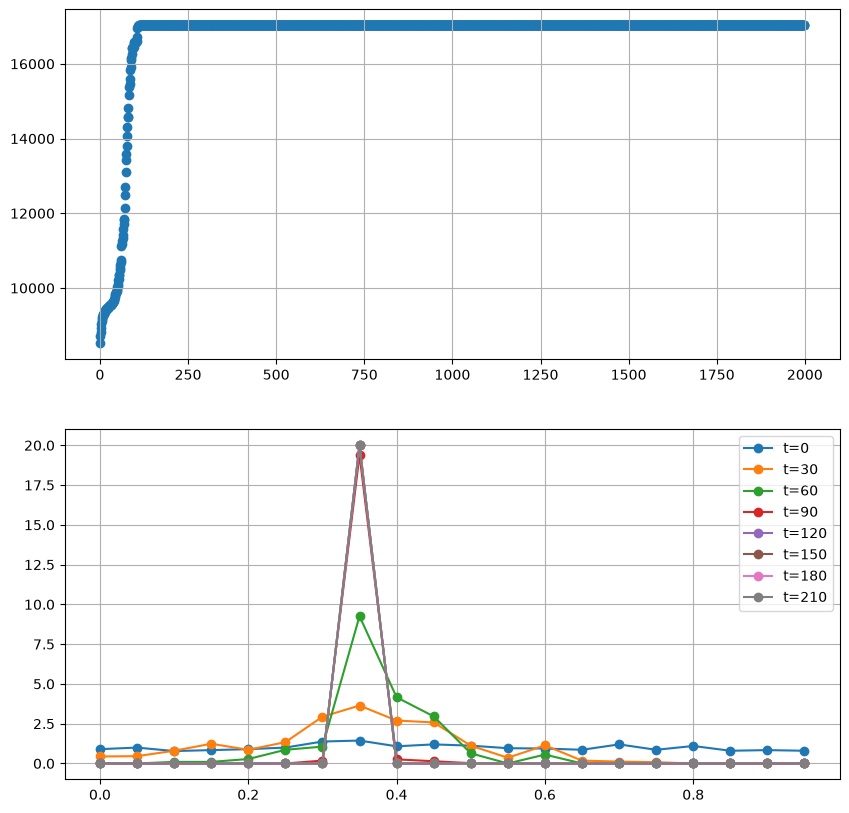

In [13]:
t = results[0]
total_payoff = np.sum(results[1], axis=1)
offers = results[2][:240]

fig, ax = plt.subplots(nrows=2, figsize=(10, 10))
ax[0].scatter(t, total_payoff)
for i in range(0, len(offers), len(offers)//8):
    density, edges = np.histogram(offers[i], bins=20, range=(0.0, 1.0), density=True)
    ax[1].plot(edges[:-1], density, '-o', label=f"t={t[i]}")

ax[0].grid()
ax[1].grid()
ax[1].legend()

plt.show()

In [ ]:
def run_UG_simulation(file,
                      N=1000,
                      alpha=0.0,
                      m=4,
                      m0_frac=0.1,
                      num_rounds=1000, 
                      update_rules=list(UPDATE_RULES_DICT.keys()), 
                      update_ratios=[1]*len(UPDATE_RULES_DICT.keys()),
                      mode="independent",
                      snapshot_frequency=100,
                      rep_id=0, 
                      ):

    # start timer
    t0 = time.perf_counter()
    # initialize graph
    G = generate_mixed_network(N=N, alpha=alpha, m=m, m0_frac=m0_frac)
    # initialize UG    
    payoffs, strategies, updates = init_UG(G, update_rules, update_ratios, mode=mode)  
    updates = np.array([RULE_TO_INT[u] for u in updates], dtype=int) # use integers instead
    # TODO: INITIALISE UPDATES AS INTEGERS INSTEAD OF STRINGS to avoid the conversion later
    N = G.number_of_nodes()
    # extract graph structure that can be reused
    edge_arr = np.array(G.edges())
    src, trg = edge_arr[:, 0], edge_arr[:, 1]
    neighbor_matr = nx.to_scipy_sparse_array(G, format='csr', nodelist=range(N))
    row_ptr = neighbor_matr.indptr
    col_indices = neighbor_matr.indices
    degrees = np.diff(row_ptr)

    num_rounds_saved = num_rounds // snapshot_frequency
    # initialise result arrays
    res_steps = np.empty(num_rounds_saved, dtype=np.int64)
    res_payoffs = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_p = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_q = np.empty((num_rounds_saved, N), dtype=np.float32)
    res_updates = np.empty((num_rounds_saved, N), dtype=np.uint8)

    # loop over UG rounds
    for round in range(num_rounds):
        # run UG
        payoffs, strategies, updates = run_UG_step(src, trg, row_ptr, col_indices, degrees, strategies, updates)

        # extract result data every couple of rounds to see evolution
        if round%snapshot_frequency == 0:
                round_idx = round//snapshot_frequency
                res_steps[round_idx] = round_idx
                res_payoffs[round_idx, :] = payoffs
                res_p[round_idx, :] = strategies[:, 0]
                res_q[round_idx, :] = strategies[:, 1]
                res_updates[round_idx, :] = updates

    # tracking the runtime
    t1 = time.perf_counter() - t0
    # write results to file
    grp = file.create_group(f"rep_{rep_id}")
    grp.create_dataset("steps", data=res_steps)
    grp.create_dataset("payoffs", data=res_payoffs)
    grp.create_dataset("p", data=res_p)
    grp.create_dataset("q", data=res_q)
    grp.create_dataset("updates", data=res_updates)

    grp.attrs["rep_id"] = rep_id
    grp.attrs["runtime_s"] = t1


In [ ]:
def run_UG_combo(alpha,
                 mode,
                 update_rules,
                 update_ratios,
                 N=1000,
                 m=4,
                 m0_frac=0.1,
                 num_reps=100,
                 num_rounds=1000, 
                 snapshot_frequency=100,
                 output_path="results/" 
                 ):

    # start timer
    t0 = time.perf_counter()
    filename = output_path + f"a{int(alpha*100)}_{mode}_{int(update_ratios[0]*100)}{update_rules[0]}_vs_{int(update_ratios[1]*100)}{update_rules[1]}.hdf5"

    # create & open file
    with h5py.File(filename, "x") as f:
        # set sim parameters as attributes
        f.attrs["alpha"] = alpha
        f.attrs["mode"] = mode
        f.attrs["update_rules"] = update_rules
        f.attrs["update_ratio"] = update_ratios
        f.attrs["num_reps"] = num_reps
        f.attrs["N"] = N
        f.attrs["snapshot_frequency"] = snapshot_frequency
        f.attrs["num_rounds"] = num_rounds

        # run desired number of repetitions of sims
        for i in range(num_reps):
            t0 = time.perf_counter()
            sim_result = run_UG_simulation(
                file=f,                
                alpha=alpha,
                update_rules=update_rules,
                update_ratios=update_ratios,
                mode=mode,
                N=N,
                m=m,
                m0_frac=m0_frac,
                num_rounds=num_rounds,
                snapshot_frequency=snapshot_frequency,
                rep_id=i,
            )
            t1 = time.perf_counter() - t0

            

In [ ]:
def run_parameter_sweep(alphas, modes, update_combos, update_ratios, N=1000, output_path="results/", 
                        num_reps=100, snapshot_frequency=100, num_rounds=1000):

    os.makedirs(output_path, exist_ok=True)
    # initialise manifest keeping track of simulations

    # Big loop of doom over parameter combinations
    combos = [dict(alpha=a, mode=m, update_rules=update_combo, update_ratios=ratio) 
              for a in alphas for m in modes for update_combo in update_combos
              for ratio in update_ratios]

    # run simulations (with joblib)
    results = Parallel(njobs=-1)(
        delayed(run_UG_combo)(
            **c, 
            N=N,
            num_rounds=num_rounds,
            snapshot_frequency=snapshot_frequency,
            num_reps=num_reps,
            output_path=output_path)
            for c in combos
        )

    # update manifest

    return None

In [16]:
# to test:
N=1000
alphas=[0.0, 1.0]
modes=["fair"]
update_combos=[["REP", "UI"]]
update_ratios=[[0.5, 0.5]]

run_parameter_sweep(alphas, modes, update_combos, update_ratios)


TODO:
- add writing results to files
- setup parameter space search (parallelize with joblib?)

So what do we want to run:
- N = 5k nodes? what if I do only 1k?
- 100/1000 realizations per setting? (Initialisation, generated network,)
- 3 alpha settings x 3 player modes x 3 update strategy pairs x 20 ratios (I'm not doing this more fine-grained) -> 540 combinations? 
- for ~10k time steps? -> probably less sufficient (maybe figure out conditions for stopping sims dynamically when stationary state is reached)

... boy oh boy this needs to be faster

## Running multiple simulations across different parameter combinations
We want to explore the following parameters:
- 3 alpha settings for network heterogeneity (0.0, 0.5, 1.0)
- 3 player modes ("fair", "pragmatic", independent)
- 3 update strategy pairs (REP vs MOR, REP vs UI, MOR vs UI)
- 21 ratios (0.0 to 1.0 in 0.05 steps) -> maybe reduce this to 10
-> Total of 549 combinations